In [1]:
import torch
import matplotlib.pyplot as plt


from laya.transformer import (
    MultiHeadSelfAttention,
    TinyTransformerEncoder,
)

In [2]:
torch.manual_seed(42)
tokens = [
    "[PAD]",
    "[MASK]",
    "the",
    "customer",
    "was",
    "charged",
    "twice",
    "today",
]

token_to_id = {token: idx for idx, token in enumerate(tokens)}

token_to_id

{'[PAD]': 0,
 '[MASK]': 1,
 'the': 2,
 'customer': 3,
 'was': 4,
 'charged': 5,
 'twice': 6,
 'today': 7}

In [3]:
sentence = [
    "the",
    "customer",
    "was",
    "charged",
    "twice",
    "today",
]

token_ids = torch.tensor([[token_to_id[token] for token in sentence]])

token_ids

tensor([[2, 3, 4, 5, 6, 7]])

In [4]:
bidirectional_encoder = TinyTransformerEncoder(
    vocab_size=len(tokens),
    max_seq_len=32,
    d_model=32,
    n_heads=4,
    d_ff=64,
    n_layers=2,
    causal=False,
)

hidden_states, attentions = bidirectional_encoder(
    token_ids,
    return_attention=True,
)

hidden_states.shape

torch.Size([1, 6, 32])

In [5]:
attention = attentions[0][0, 0]

attention

tensor([[0.0929, 0.2892, 0.1110, 0.2456, 0.1704, 0.0910],
        [0.1528, 0.1544, 0.2146, 0.1927, 0.1057, 0.1798],
        [0.2742, 0.0982, 0.1089, 0.1590, 0.1335, 0.2262],
        [0.1755, 0.1495, 0.1677, 0.1640, 0.1555, 0.1878],
        [0.1911, 0.1402, 0.1335, 0.2142, 0.1054, 0.2156],
        [0.1370, 0.1678, 0.1851, 0.1488, 0.2435, 0.1178]],
       grad_fn=<SelectBackward0>)

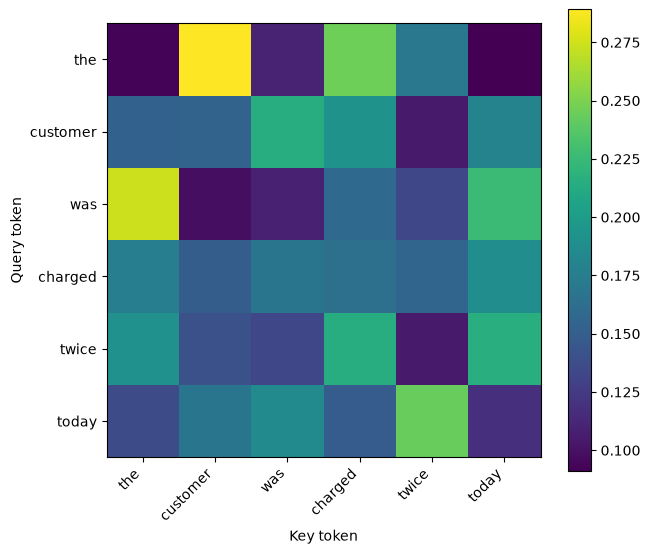

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(attention.detach().numpy())

ax.set_xticks(range(len(sentence)))
ax.set_yticks(range(len(sentence)))

ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticklabels(sentence)

ax.set_xlabel("Key token")
ax.set_ylabel("Query token")

fig.colorbar(im)

plt.show()

In [7]:
causal_encoder = TinyTransformerEncoder(
    vocab_size=len(tokens),
    max_seq_len=32,
    d_model=32,
    n_heads=4,
    d_ff=64,
    n_layers=2,
    causal=True,
)

_, causal_attentions = causal_encoder(
    token_ids,
    return_attention=True,
)

causal_attention = causal_attentions[0][0, 0]

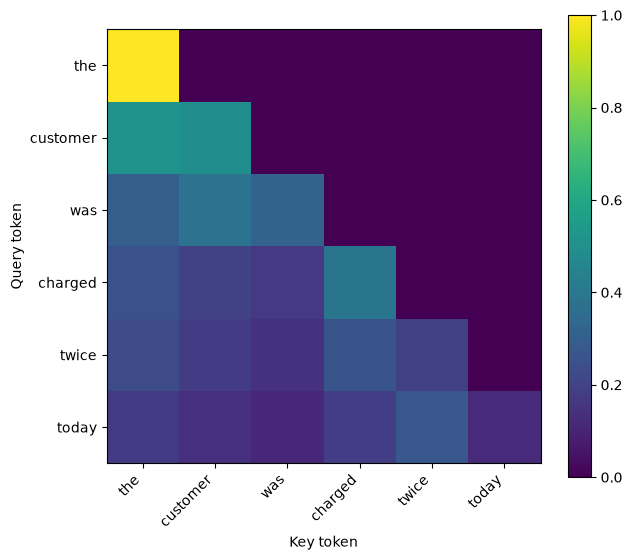

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(causal_attention.detach().numpy())

ax.set_xticks(range(len(sentence)))
ax.set_yticks(range(len(sentence)))

ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticklabels(sentence)

ax.set_xlabel("Key token")
ax.set_ylabel("Query token")

fig.colorbar(im)

plt.show()